## Ensemble Learning Techniques: A Quick Overview 

Ensemble learning is a machine learning technique where multiple models (weak learners [*they cannot learn more than 50 or 60%]) are combined to improve accuracy, stability, and robustness. Instead of relying on a single model, ensembles leverage the wisdom of the crowd to make better predictions.

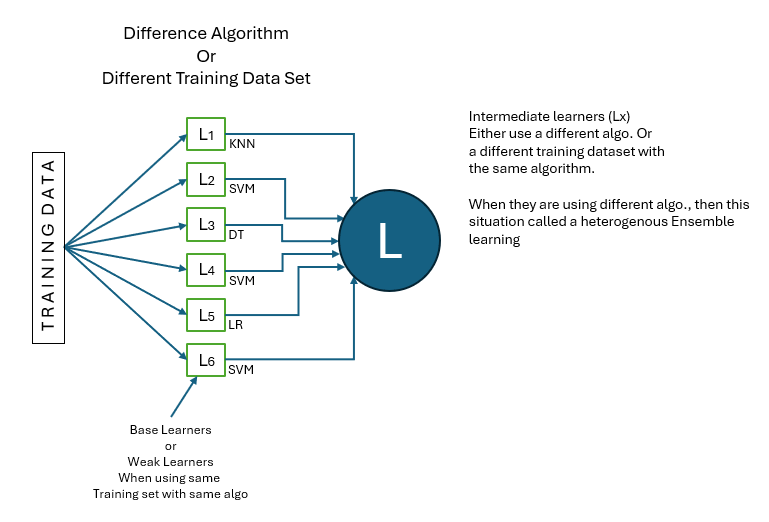

### Type of Ensemble Learning Techniques

1. Bagging (Bootstrap Aggregating) - Reduce Overfitting


    a. Trains multiple models independently on different random subsets of data. \
    b. Combines predictions using majority voting (classification) or averaging (regression). \
    c. Example Algorithm: Random Forest (ensemble of decision trees). \
    d. Good for high-variance models (e.g., Decision Trees). \
    e. Doesn’t improve weak base models much.

2. Boosting - Improving Accurance \
     Let's say, We've some trainging data and from that training data, I selected some random data and create another dataset. It may possible that few among all data available in all small samples (called sampling and replacements). These small datasets called bootstrap samples. We have gererated these because we can trainined classifiers on these datasets. Now all from all training classifiers (C1, C2, ... , Cn), generate final classifiers which is basically more accurate than any weak classifiers.

    a. Trains models sequentially, where each new model corrects errors made by the previous one. \
    b. Assigns higher weights to misclassified points. \
    c. Improves accuracy significantly. \
    d. Can overfit if not tuned properly. \
    e. Example Algorithms: \
    &emsp; i.   **AdaBoost (Adaptive Boosting)** – Adaptive Boosting (AdaBoost) is a Boosting algorithm that improves model accuracy by combining multiple weak classifiers (typically Decision Trees) into a strong classifier. It focuses on misclassified points, assigning them higher weights so that future models correct their errors. Adjusts weights to focus on hard-to-classify points. \
    &emsp; ii.  **Gradient Boosting (GBM, XGBoost, LightGBM, CatBoost)** – Uses gradient descent to improve errors. 



### How AdaBoost Works?

AdaBoost builds multiple weak learners sequentially and adjusts the importance (weights) of each training instance after every iteration.

In [10]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import (accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix)  

In [15]:
df = pd.read_csv('Data/breastcan_dataset.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
df.diagnosis.value_counts(normalize=True)

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

In [17]:
df['diagnosis'] = np.where(df['diagnosis'] == 'M', 1, 0)


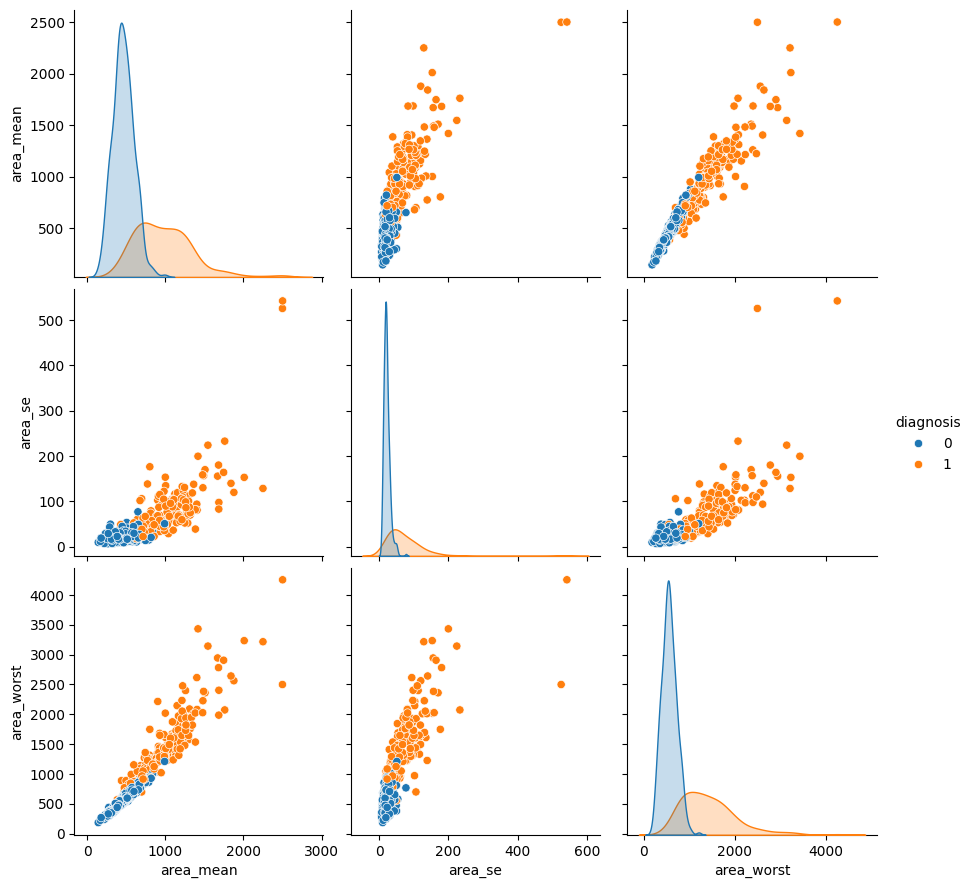

In [ ]:
area = df[['area_mean', 'area_se', 'area_worst' ,'diagnosis']]
sns.pairplot(area, hue='diagnosis', height=3)
sns.axisgrid.le